## Import Libraries

In [60]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

## Read the Data

In [41]:
df = pd.read_csv(r"C:\Users\marwan\Downloads\titanic\train.csv")

In [42]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [44]:
df.shape

(891, 12)

In [45]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [46]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [47]:
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

In [48]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [49]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

## separate x, y

In [50]:
x = df.drop('Survived', axis =1)
y= df['Survived']

In [51]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S
887,1,female,19.0,0,0,30.0000,S
888,3,female,NaN,1,2,23.4500,S
889,1,male,26.0,0,0,30.0000,C


In [52]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

## train , test

In [56]:
x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.2,
        random_state=42)

## Preprocessing

In [57]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [58]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [67]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [68]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [69]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, ["Pclass", "Age", "SibSp", "Parch", "Fare"]),
    ("cat", categorical_pipeline, ["Sex", "Embarked"])
])

## model selection

In [73]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [75]:
model_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Hyperparameters

In [77]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

## Grid Search + Cross Validation

In [78]:
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy"
)

In [80]:
grid_search.fit(x_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


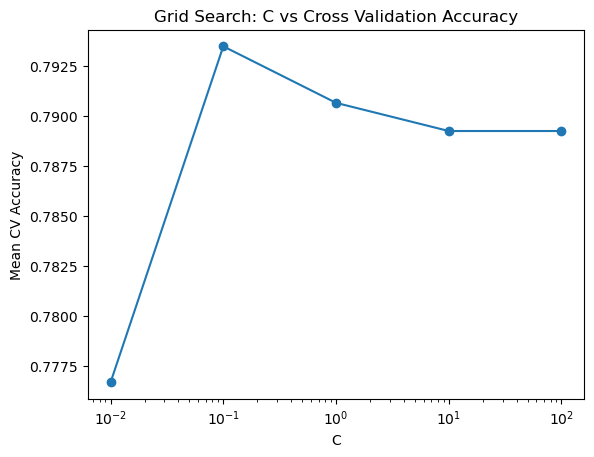

In [103]:
import matplotlib.pyplot as plt

results = pd.DataFrame(grid_search.cv_results_)

plt.plot(
    results["param_model__C"],
    results["mean_test_score"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Mean CV Accuracy")
plt.title("Grid Search: C vs Cross Validation Accuracy")

plt.show()

### Best_params

In [85]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 0.1}


### Best cv_score

In [86]:
print("Best CV Score:")
print(grid_search.best_score_)

Best CV Score:
0.7934896089825667


## Predictions the Test Data

In [88]:
y_pred = grid_search.predict(x_test)

In [92]:
y_pred[0 : 11]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0])

In [94]:
y_test[0 : 11]

709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
137    0
Name: Survived, dtype: int64

## Accuracy

In [95]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8044692737430168


In [107]:
cv_accuracy = grid_search.best_score_
test_accuracy = accuracy

print("CV Accuracy:", cv_accuracy)
print("Test Accuracy:", test_accuracy)

CV Accuracy: 0.7934896089825667
Test Accuracy: 0.8044692737430168


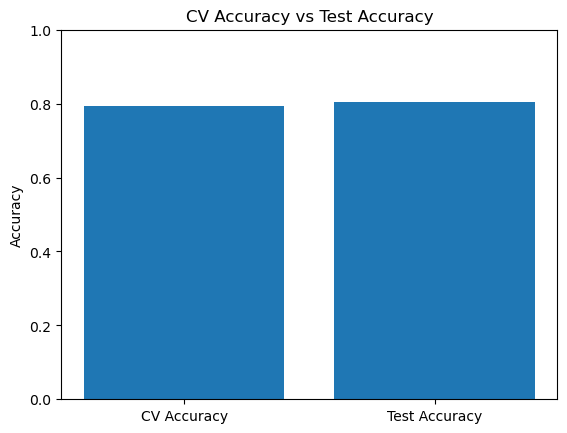

In [108]:
plt.bar(
    ["CV Accuracy", "Test Accuracy"],
    [cv_accuracy, test_accuracy]
)

plt.ylabel("Accuracy")
plt.title("CV Accuracy vs Test Accuracy")

plt.ylim(0, 1)

plt.show()

## Classification Report

In [99]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



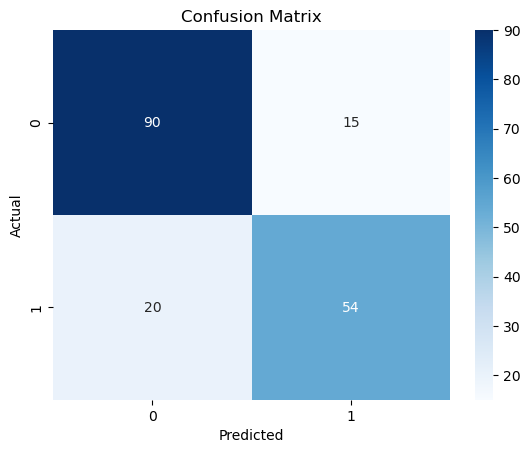

In [104]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

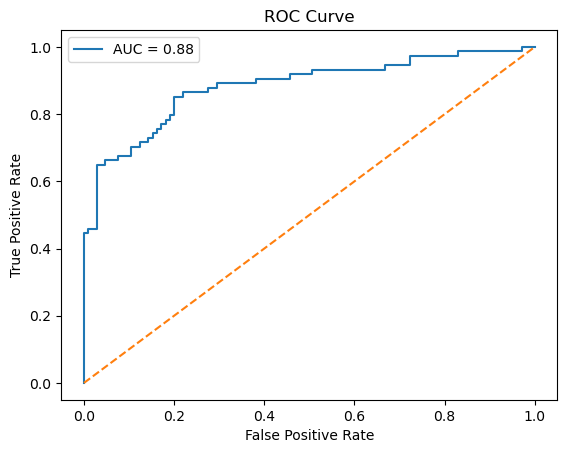

In [106]:
# ROC Curve + AUC

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = grid_search.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Predictions

In [102]:
print("Actual:")
print(y_test.head(10).values)

print("Predicted:")
print(y_pred[:10])

Actual:
[1 0 0 1 1 1 1 0 1 1]
Predicted:
[0 0 0 1 1 1 1 0 1 1]


## Conclusion